<a href="https://colab.research.google.com/github/Spyros-Varsamis/pairs-trading-mean-reversion/blob/main/Copy_of_pairs_trading_mean_reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project we'll test whether a pair of stocks follows mean reversion, and if it does, build a trading strategy around it. We'll go through three different strategies you could use to trade the spread, along with a GARCH model for handling volatility, and at the end we'll backtest everything and run a Monte Carlo simulation to see how solid the results really are.

Let's start by downloading the libraries we need. Quick note: we're using **daily data** throughout this project, because we're dealing with **discrete time series models** — our data comes in fixed, evenly-spaced steps (one price per day), not a continuous stream of prices.

Let's get going!!

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import sys
print(sys.executable)
!{sys.executable} -m pip install arch --break-system-packages
from arch import arch_model


/opt/anaconda3/bin/python


## Step 1: Getting and Preparing the Data

Now that our libraries are ready, let's grab daily prices for two stocks, A and B, and see how they've moved over time. Since the two stocks trade at very different price levels, we can't compare them directly so we'll **normalize** both series to start at 100. This puts them on the same scale and lets us build the **spread**: the difference between the two normalized prices.

This spread is the actual thing we're going to trade think of it as one combined position, long one stock and short the other. If it wanders far from its normal level, we're betting it eventually comes back.

### Why we normalize the prices

Stock A and Stock B almost certainly trade at very different price levels — one might be $190 a share, the other $420. Comparing their raw prices directly wouldn't tell us much, since a $5 move means something completely different depending on which stock we're looking at.

To fix this, we **normalize** both price series — we rebase each one so it starts at exactly 100 on day one, and every day after that is expressed as a percentage of where it started:

$$\text{normalized price}_t = \frac{\text{price}_t}{\text{price}_0} \times 100$$

where $\text{price}_t$ is the stock's price on a given day, and $\text{price}_0$ is its price on the very first day of the period. This expresses every day's price as a percentage of where the stock started, putting both stocks on the same, comparable scale regardless of how differently priced they are in dollars.
### How a trade actually works

A trade on the spread isn't a bet on Stock A or Stock B individually it's a bet on the **gap between them** returning to normal. Because of this, every trade is really two trades happening at once: we buy one stock while simultaneously selling the other.

**If the spread goes unusually high** — meaning A looks expensive relative to B, compared to their normal relationship — we **short A** and **go long B**. We're betting the gap narrows back to normal, whether that happens because A falls, B rises, or some combination of both. Since we're positioned on both sides, we profit from the correction regardless of which stock actually does the moving.

**If the spread goes unusually low** — A looks cheap relative to B — we do the opposite: **go long A** and **short B**, betting the gap widens back out to normal.




[*********************100%***********************]  2 of 2 completed


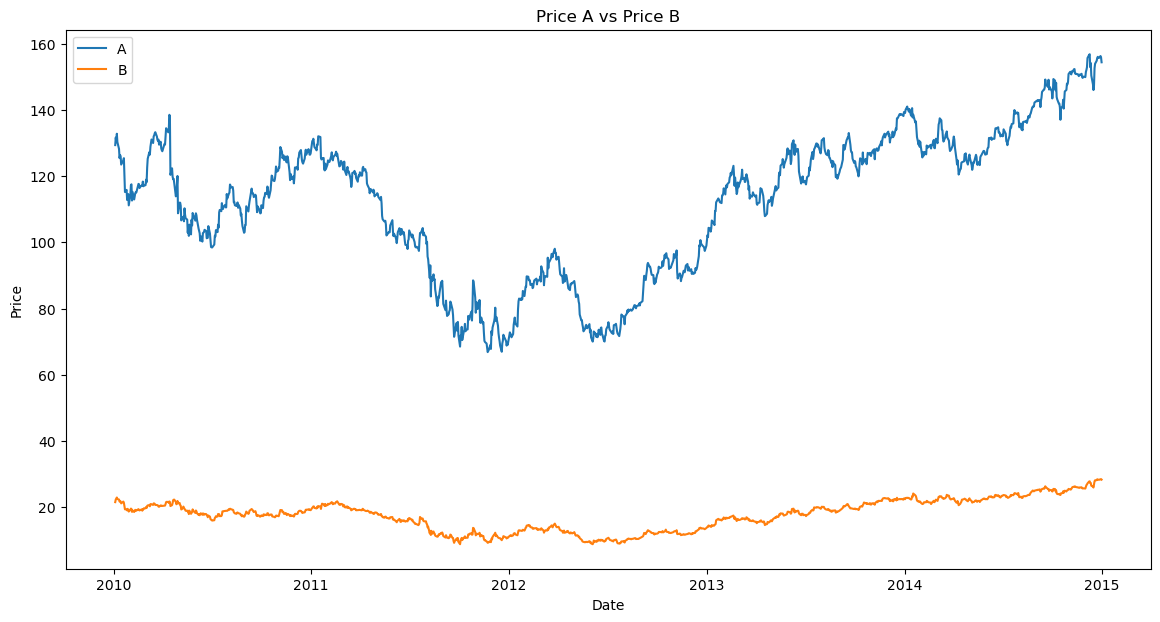

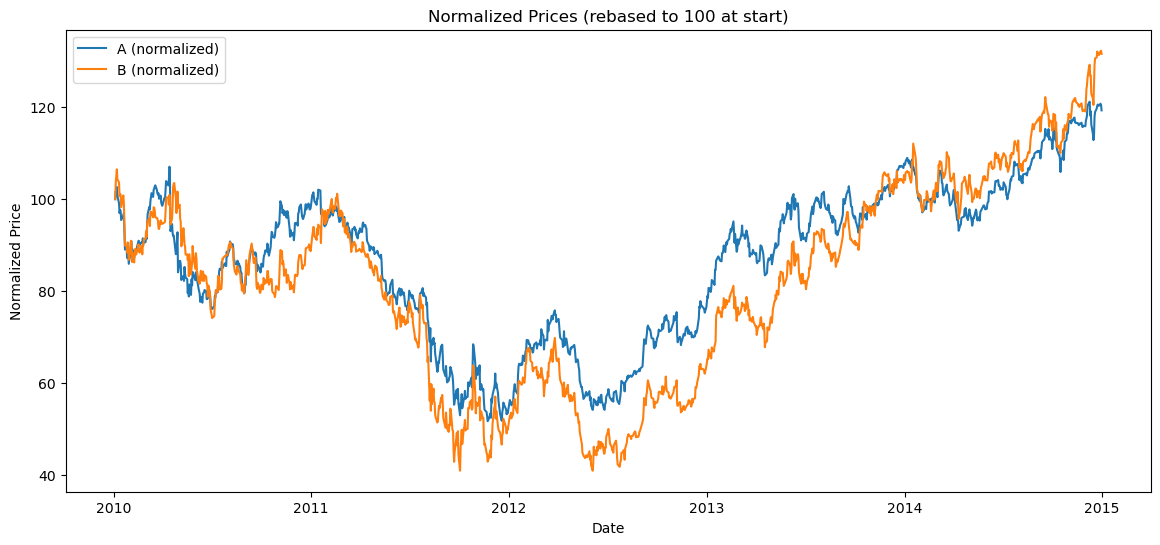

Number of missing values in each column:
A    0
B    0
dtype: int64
(1258, 2)
                     A          B
Date                             
2010-01-04  129.387405  21.508478
2010-01-05  131.674866  22.294783
2010-01-06  130.269470  22.580078
2010-01-07  132.818604  22.907116
2010-01-08  130.306854  22.440905


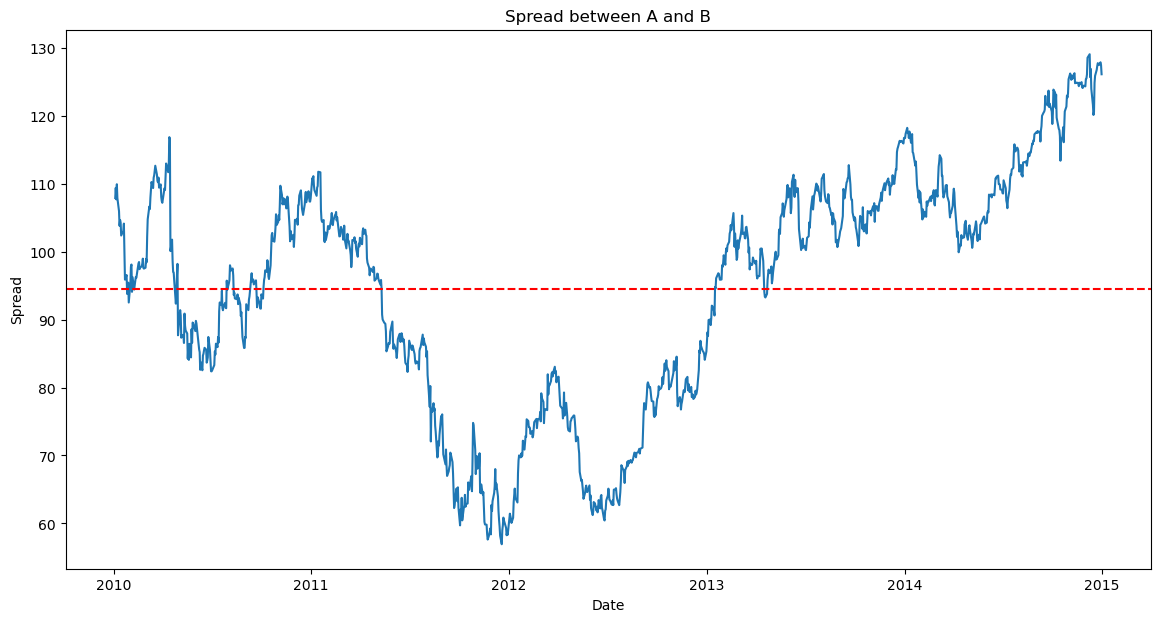

In [ ]:
ticker_a = "GS"
ticker_b = "MS"
date_1 = "2010-01-01"
date_2 = "2015-01-01"

df = yf.download([ticker_a, ticker_b], start= date_1, end= date_2)

price_a = df['Close'][ticker_a]
price_b = df['Close'][ticker_b]


plt.figure(figsize=(14, 7))
plt.plot(price_a, label='A')
plt.plot(price_b, label='B')
plt.legend()
plt.title('Price A vs Price B')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

prices = pd.DataFrame({'A': price_a, 'B': price_b})
prices= prices.dropna()

anchor_a = prices['A'].iloc[0]
anchor_b = prices['B'].iloc[0]

norm_a = prices['A'] / anchor_a * 100
norm_b = prices['B'] / anchor_b * 100

spread_norm = norm_a - norm_b

plt.figure(figsize=(14, 6))
plt.plot(norm_a, label='A (normalized)')
plt.plot(norm_b, label='B (normalized)')
plt.legend()
plt.title('Normalized Prices (rebased to 100 at start)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.show()

print('Number of missing values in each column:')
print(prices.isna().sum())

spread = abs(price_a - price_b)

mean_spread = spread.mean()

print(prices.shape)
print(prices.head())



spread.head()
plt.figure(figsize=(14, 7))
plt.plot(spread)
plt.axhline(mean_spread, color='r', linestyle='--', label='Mean Spread')
plt.title('Spread between A and B')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.show()



## Step 2: Does This Spread Actually Mean-Revert?

Before we build any trading strategy, we need real evidence that this spread reverts to a stable center instead of just wandering off randomly forever. We'll run four checks here, each asking a slightly different question.

**1. Correlation** - Are the two stocks even related to each other in the first place?

$$r = \frac{\sum (a_i - \bar{a})(b_i - \bar{b})}{\sqrt{\sum (a_i - \bar{a})^2 \cdot \sum (b_i - \bar{b})^2}}$$

calculated on daily *returns*, not raw prices — this avoids a fake-looking correlation that can appear just because both stocks trend upward over time.

**2. Lambda** - We run a regression: yesterday's spread level as the input, today's change in the spread as the output.

$$\Delta \text{spread}_t = \alpha + \lambda \cdot \text{spread}_{t-1} + \varepsilon_t$$

The regression finds the best-fit relationship between the two, and $\lambda$ — the slope — tells us whether high spread values tend to fall back down and low values tend to rise back up. A **negative** $\lambda$ means the spread is genuinely being pulled back toward its average — the core signature of mean reversion. The same regression also gives us a t-statistic, which tells us whether that pull is strong enough to trust or could just be random noise.


**3. Half-life** - Assuming the spread does revert, how long does it typically take?

$$\text{half-life} = \frac{\ln(2)}{|\lambda|}$$

This tells us, in practical terms, roughly how many days we'd expect to hold a position before the mispricing corrects.

**4. ADF Test (Augmented Dickey-Fuller)** - This is the formal, textbook-correct version of the same question Test 2 just asked. It runs a very similar regression internally — yesterday's level predicting today's change — but with extra lagged terms added in to clean up any leftover patterns in the daily changes, keeping the test's underlying math valid:

$$\Delta \text{spread}_t = \alpha + \lambda \cdot \text{spread}_{t-1} + \sum_{i=1}^{p} \phi_i \Delta \text{spread}_{t-i} + \varepsilon_t$$

The key difference from Test 2: instead of judging the result against the same generic cutoff, ADF compares it against a special set of reference values (Dickey-Fuller critical values) built specifically for this kind of test — since a series that might be a random walk behaves differently than ordinary regression assumptions expect. That makes ADF the properly calibrated, rigorous version — passing this test is stronger evidence of real mean reversion than passing Test 2 alone.

First test: Correlation

PASS-The two stocks are highly correlated.
Correlation: 0.8105


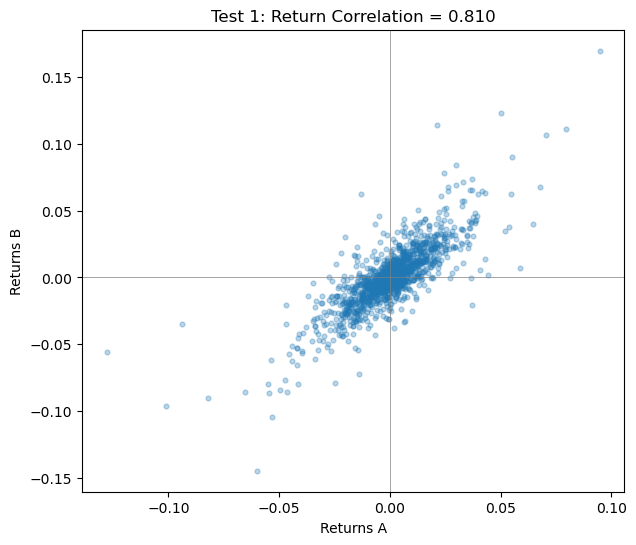


Second test: Lambda 

PASS - mean reversion direction confirmed
PASS - lambda is statistically significant
Lambda: -0.0094
T-stat: -2.2025
P-value: 0.027809


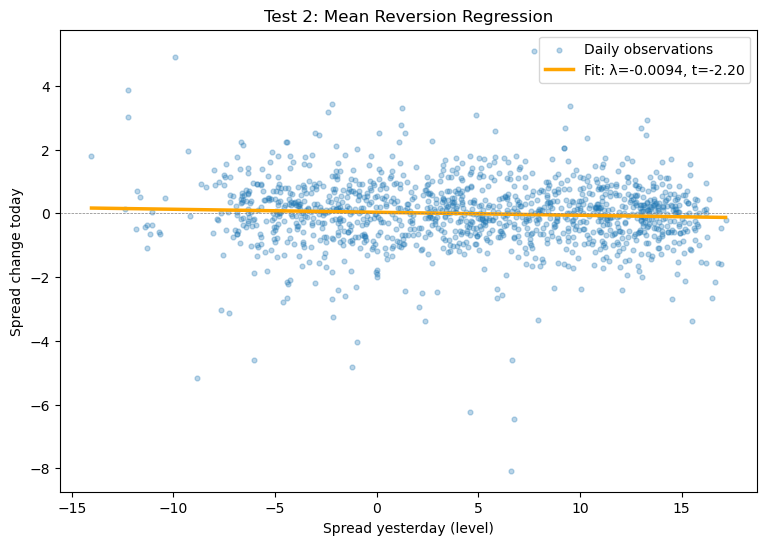


Third test: Half-life of mean reversion

FAIL - Half-life is 73.48 days, which is greater than 30 days


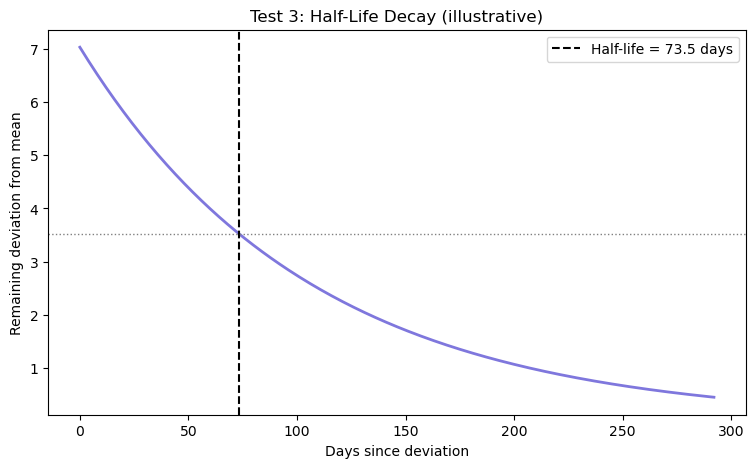


Fourth test: Stationarity of the spread, using Augmented Dickey-Fuller test

FAIL - spread is not stationary (could be a random walk)
ADF statistic: -1.6727
ADF p-value: 0.445255


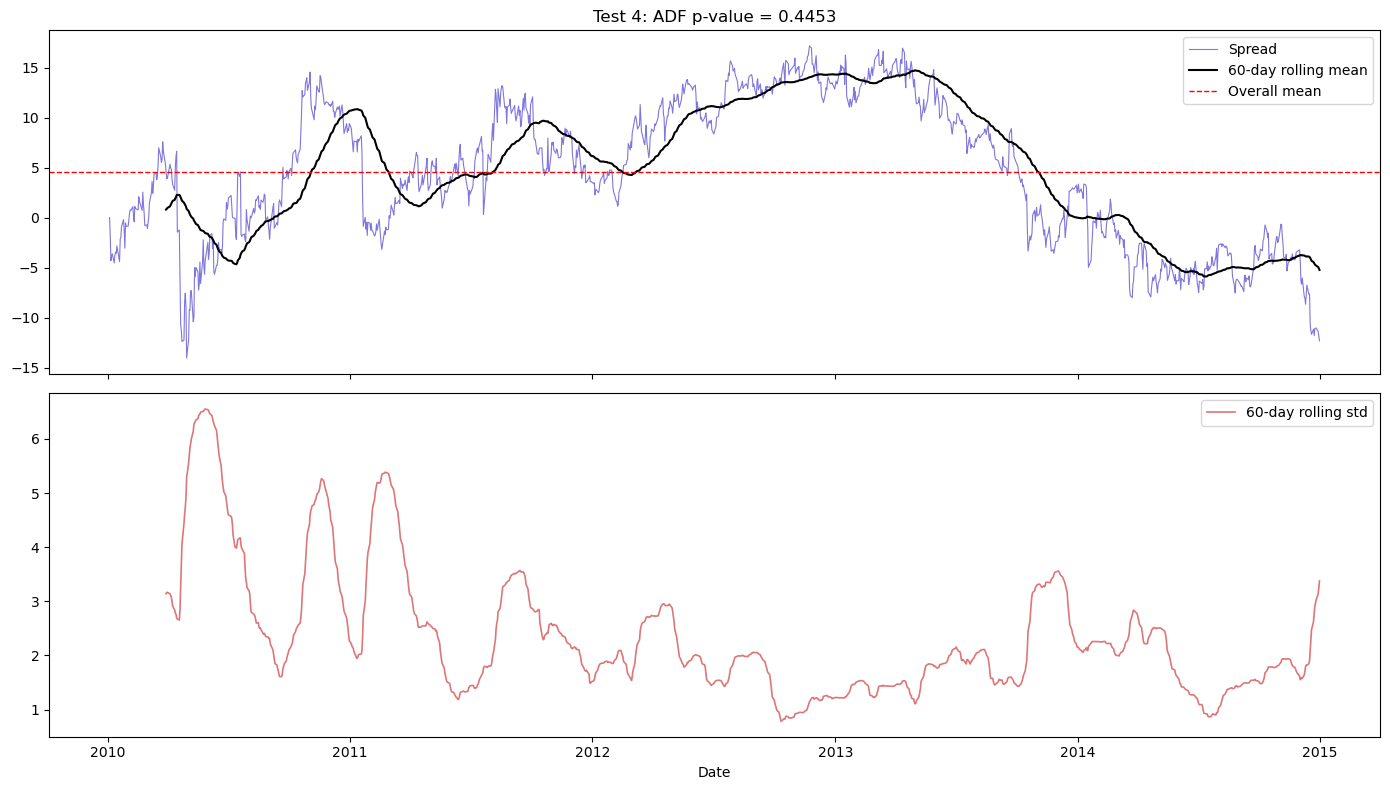

In [ ]:
print("First test: Correlation")
returns_a = prices['A'].pct_change()
returns_b = prices['B'].pct_change()
correlation = returns_a.corr(returns_b)
if correlation > 0.7:
    print(f"\nPASS-The two stocks are highly correlated.")
else:
    print("FAIL-The two stocks are not highly correlated.")
print(f'Correlation: {correlation:.4f}')
plt.figure(figsize=(7, 6))
plt.scatter(returns_a, returns_b, alpha=0.3, s=12)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('Returns A')
plt.ylabel('Returns B')
plt.title(f'Test 1: Return Correlation = {correlation:.3f}')
plt.show()
print(f'\nSecond test: Lambda ')
delta_spread = spread_norm.diff().dropna()
spread_lag = spread_norm.shift(1).dropna()

X2 = sm.add_constant(spread_lag)
model2 = sm.OLS(delta_spread, X2).fit()

lambda_ = model2.params.iloc[1]
t_stat  = model2.tvalues.iloc[1]
p_value = model2.pvalues.iloc[1]

if lambda_ < 0:
    print(f"\nPASS - mean reversion direction confirmed")
    lambda_pass = True
else:
    print(f"\nFAIL - no mean reversion (momentum instead)")
    lambda_pass = False


if abs(t_stat) > 2.0:
    print("PASS - lambda is statistically significant")
    tstat_pass = True
else:
    print("FAIL - lambda could be random noise")
    tstat_pass = False

print(f"Lambda: {lambda_:.4f}")
print(f"T-stat: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
plt.figure(figsize=(9, 6))
plt.scatter(spread_lag, delta_spread, alpha=0.3, s=12, label='Daily observations')

x_line = spread_lag.sort_values()
y_line = model2.params.iloc[0] + lambda_ * x_line
plt.plot(x_line, y_line, color='orange', lw=2.5,
         label=f'Fit: λ={lambda_:.4f}, t={t_stat:.2f}')

plt.axhline(0, color='gray', lw=0.5, linestyle='--')
plt.xlabel('Spread yesterday (level)')
plt.ylabel('Spread change today')
plt.title('Test 2: Mean Reversion Regression')
plt.legend()
plt.show()

print(f"\nThird test: Half-life of mean reversion")
half_life = np.log(2) / abs(lambda_)
if half_life < 30:
    print(f"\nPASS - Half-life is {half_life:.2f} days, which is less than 30 days")
    half_life_pass = True
else:
    print(f"\nFAIL - Half-life is {half_life:.2f} days, which is greater than 30 days")
    half_life_pass = False

days = np.arange(0, int(half_life * 4))
start_deviation = spread_norm.std()
decay = start_deviation * (0.5) ** (days / half_life)

plt.figure(figsize=(9, 5))
plt.plot(days, decay, color='#7F77DD', lw=2)
plt.axvline(half_life, color='black', linestyle='--', label=f'Half-life = {half_life:.1f} days')
plt.axhline(start_deviation / 2, color='gray', linestyle=':', lw=1)
plt.xlabel('Days since deviation')
plt.ylabel('Remaining deviation from mean')
plt.title('Test 3: Half-Life Decay (illustrative)')
plt.legend()
plt.show()

print(f"\nFourth test: Stationarity of the spread, using Augmented Dickey-Fuller test")
adf_result = adfuller(spread_norm)

adf_stat = adf_result[0]
adf_pvalue = adf_result[1]


if adf_pvalue < 0.05:
    print(f"\nPASS - spread is stationary (mean-reverting)")
    adf_pass = True
else:
    print(f"\nFAIL - spread is not stationary (could be a random walk)")
    adf_pass = False
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")

rolling_mean = spread_norm.rolling(window=60).mean()
rolling_std = spread_norm.rolling(window=60).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spread_norm, color='#7F77DD', lw=0.8, label='Spread')
axes[0].plot(rolling_mean, color='black', lw=1.5, label='60-day rolling mean')
axes[0].axhline(spread_norm.mean(), color='red', linestyle='--', lw=1, label='Overall mean')
axes[0].set_title(f'Test 4: ADF p-value = {adf_pvalue:.4f}')
axes[0].legend()

axes[1].plot(rolling_std, color='#DD7777', lw=1.2, label='60-day rolling std')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()



## Step 3: Train/Test Split, and Our First Trading Strategy

Before this section, everything we calculated used the full dataset. But to fairly test a strategy, we need to simulate what a real trader could have actually known *at the time* — so we split the data into a **train** period and a **test** period.

We calculate everything below — the average spread level, its typical volatility, and its reversion strength — using **train data only**. Then we apply those numbers to the untouched **test** period, and see how the strategy would have actually performed on data it never got to learn from. This is what makes the backtest honest: if we let the strategy learn from the same data it's being tested on, we'd just be grading it on questions it already saw the answers to.

Note that we also re-normalize here using the anchor prices from the *start of the training period only* — the same anchor then gets reused on the test period too, so nothing about the test period leaks into how the spread is built.

### The trading rule

We measure how far today's spread is from "normal" using a **z-score**:

$$z = \frac{\text{spread}_t - \mu}{\sigma}$$

where $\mu$ is the average spread level and $\sigma$ is its typical volatility, both calculated from train data only.

- If $z > 2$, the spread is unusually high — we **short** it, betting it falls back down.
- If $z < -2$, the spread is unusually low — we **go long**, betting it rises back up.
- Once in a trade, we exit either by **taking profit** (the z-score comes back close to 0, meaning the spread returned to normal) or by **hitting a stop loss** (the z-score keeps growing further away from normal, meaning the trade went against us).

This first version measures $\sigma$ using **one fixed number**, calculated once from the training period and never updated — the simplest possible version of the strategy. In the next section, we'll build a version that updates its sense of "normal" continuously, and compare the two.

Train: 1006 days, 2010-01-04 00:00:00 to 2013-12-31 00:00:00
Test:  252 days, 2014-01-02 00:00:00 to 2014-12-31 00:00:00

Anchor A (train start): 129.3874
Anchor B (train start): 21.5085

Train mu (mean): 6.7176
Train sigma (std): 5.9709

Train lambda: -0.0175
Train t-stat: -3.0091
Train half-life: 39.6 days
No trades were taken in this period.


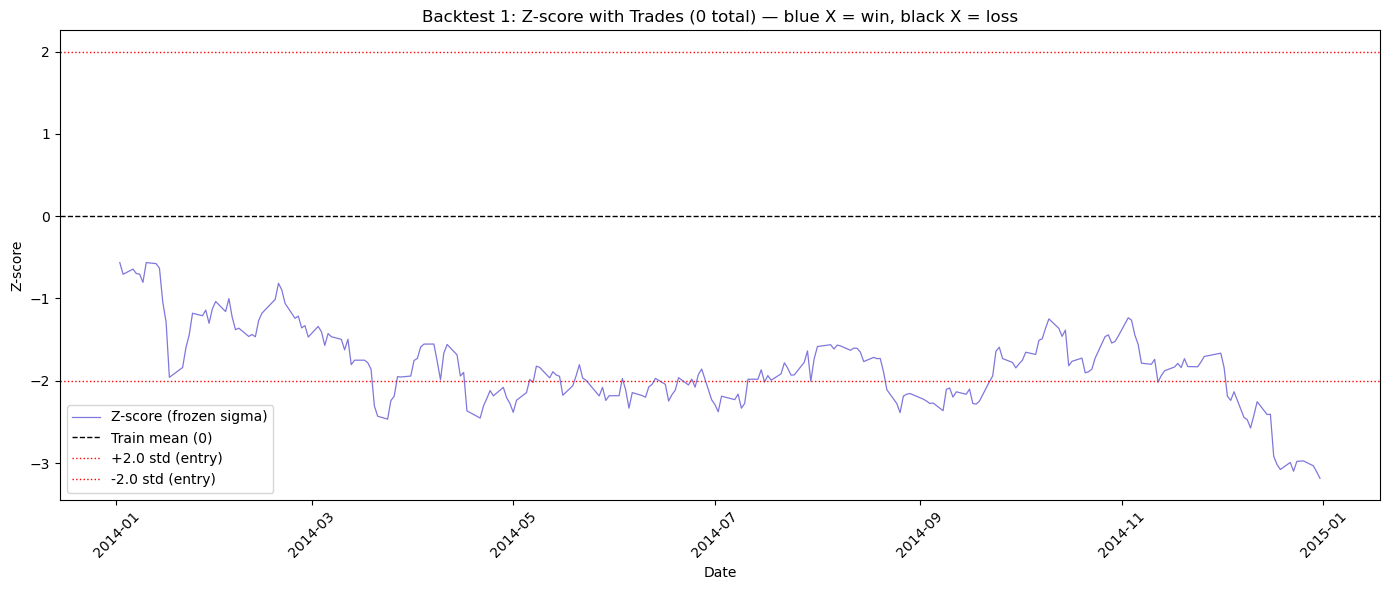

Test z-score mean: -1.8408
Test z-score std:  0.4786


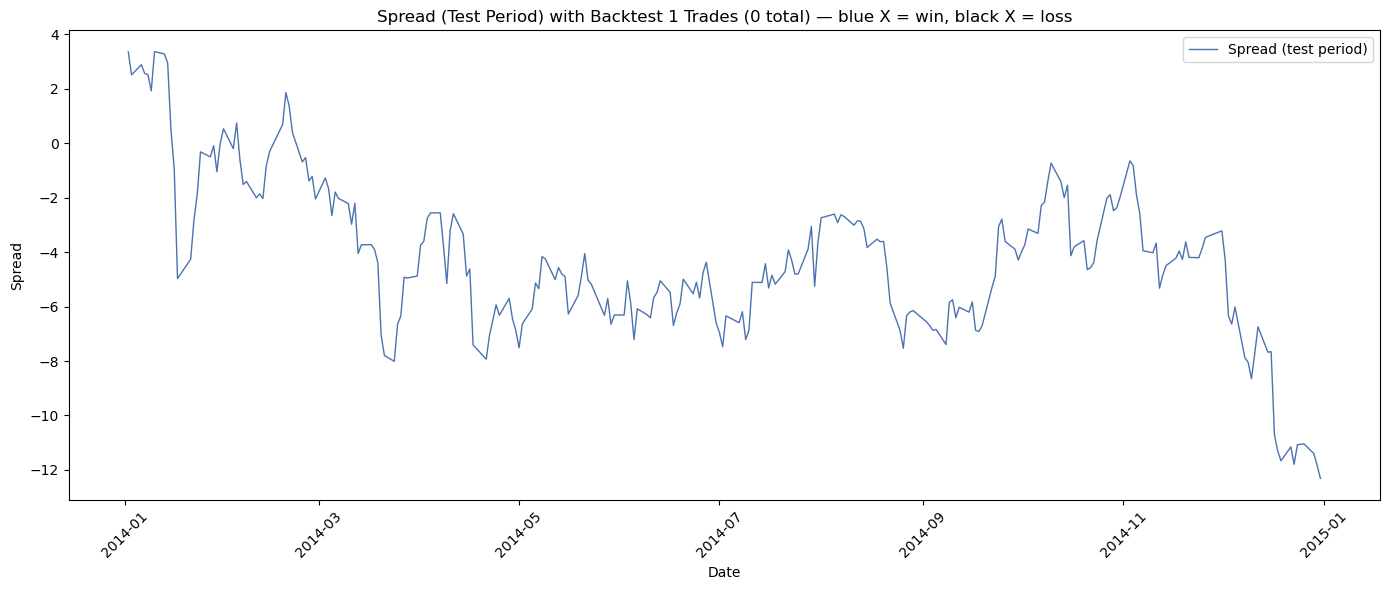

In [ ]:
split_index = int(len(prices) * 0.8)
train = prices.iloc[:split_index]
test = prices.iloc[split_index:]

print(f"Train: {len(train)} days, {train.index.min()} to {train.index.max()}")
print(f"Test:  {len(test)} days, {test.index.min()} to {test.index.max()}")

anchor_a_train = train['A'].iloc[0]
anchor_b_train = train['B'].iloc[0]

print(f"\nAnchor A (train start): {anchor_a_train:.4f}")
print(f"Anchor B (train start): {anchor_b_train:.4f}")

norm_a_train = train['A'] / anchor_a_train * 100
norm_b_train = train['B'] / anchor_b_train * 100
spread_train = norm_a_train - norm_b_train

mu_train = spread_train.mean()
sigma_train = spread_train.std()

print(f"\nTrain mu (mean): {mu_train:.4f}")
print(f"Train sigma (std): {sigma_train:.4f}")


delta_spread_train = spread_train.diff().dropna()
spread_lag_train = spread_train.shift(1).dropna()

X_train2 = sm.add_constant(spread_lag_train)
model_train2 = sm.OLS(delta_spread_train, X_train2).fit()

lambda_train = model_train2.params.iloc[1]
t_stat_train = model_train2.tvalues.iloc[1]

print(f"\nTrain lambda: {lambda_train:.4f}")
print(f"Train t-stat: {t_stat_train:.4f}")
half_life_train = np.log(2) / abs(lambda_train)
print(f"Train half-life: {half_life_train:.1f} days")


norm_a_test = test['A'] / anchor_a_train * 100
norm_b_test = test['B'] / anchor_b_train * 100
spread_test = norm_a_test - norm_b_test
z_test = (spread_test - mu_train) / sigma_train

ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 3.5

position = 0
entry_price = None
entry_date = None

trades = []

for date, z in z_test.items():
    if position == 0:
        if ENTRY_Z < z <= STOP_Z:
            position = -1
            entry_price = spread_test.loc[date]
            entry_date = date
        elif -STOP_Z <= z < -ENTRY_Z:
            position = 1
            entry_price = spread_test.loc[date]
            entry_date = date
    else:
        took_profit = abs(z) < EXIT_Z
        hit_stop_loss = abs(z) > STOP_Z

        if took_profit or hit_stop_loss:

            exit_price = spread_test.loc[date]

            if position == 1:
                pnl = exit_price - entry_price
            else:
                pnl = entry_price - exit_price

            if position == 1:
                direction = 'long'
            else:
                direction = 'short'

            days_held = (date - entry_date).days

            trade_record = {
                'entry_date': entry_date,
                'exit_date': date,
                'direction': direction,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'pnl': pnl,
                'days_held': days_held
            }

            trades.append(trade_record)

            position = 0
            entry_price = None
            entry_date = None


trades_df = pd.DataFrame(trades)

num_trades = len(trades_df)

if num_trades == 0:
    print("No trades were taken in this period.")
else:
    wins = trades_df[trades_df['pnl'] > 0]
    losses = trades_df[trades_df['pnl'] <= 0]

    win_rate = len(wins) / num_trades
    avg_win = wins['pnl'].mean() if len(wins) > 0 else 0
    avg_loss = losses['pnl'].mean() if len(losses) > 0 else 0
    total_pnl = trades_df['pnl'].sum()
    avg_days_held = trades_df['days_held'].mean()


    print(f"\nBACKTEST RESULTS")
    print(f"\nNumber of trades:   {num_trades}")
    print(f"Winning trades:     {len(wins)}")
    print(f"Losing trades:      {len(losses)}")
    print(f"Win rate:           {win_rate:.1%}")
    print(f"Average win:        {avg_win:.2f}")
    print(f"Average loss:       {avg_loss:.2f}")
    print(f"Total P&L:          {total_pnl:.2f}")
    print(f"Average days held:  {avg_days_held:.1f}")



plt.figure(figsize=(14, 6))
plt.plot(z_test, color='#7F77DD', lw=0.9, label='Z-score (frozen sigma)', zorder=1)
plt.axhline(0, color='black', linestyle='--', lw=1, label='Train mean (0)')
plt.axhline(ENTRY_Z, color='red', linestyle=':', lw=1, label=f'+{ENTRY_Z} std (entry)')
plt.axhline(-ENTRY_Z, color='red', linestyle=':', lw=1, label=f'-{ENTRY_Z} std (entry)')

labeled_long = False
labeled_short = False

for _, trade in trades_df.iterrows():
    entry_z = z_test.loc[trade['entry_date']]
    exit_z = z_test.loc[trade['exit_date']]

    if trade['direction'] == 'long':
        color = 'green'
        marker = '^'
        label = None if labeled_long else 'Long entry'
        labeled_long = True
    else:
        color = 'red'
        marker = 'v'
        label = None if labeled_short else 'Short entry'
        labeled_short = True

    plt.scatter(trade['entry_date'], entry_z, color=color, marker=marker, s=100, zorder=3, label=label)

    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(trade['exit_date'], exit_z, color=outcome_color, marker='x', s=80, zorder=3)

    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([trade['entry_date'], trade['exit_date']], [entry_z, exit_z],
             color=outcome_color, linestyle=line_style, lw=1.5, alpha=0.7, zorder=2)

plt.title(f'Backtest 1: Z-score with Trades ({len(trades_df)} total) — blue X = win, black X = loss')
plt.xlabel('Date')
plt.ylabel('Z-score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Test z-score mean: {z_test.mean():.4f}")
print(f"Test z-score std:  {z_test.std():.4f}")

plt.figure(figsize=(14, 6))
plt.plot(spread_test, color='#4C72B0', lw=1.0, label='Spread (test period)', zorder=1)

labeled_long = False
labeled_short = False

for _, trade in trades_df.iterrows():
    if trade['direction'] == 'long':
        color = 'green'
        marker = '^'
        label = None if labeled_long else 'Long entry'
        labeled_long = True
    else:
        color = 'red'
        marker = 'v'
        label = None if labeled_short else 'Short entry'
        labeled_short = True

    plt.scatter(trade['entry_date'], trade['entry_price'], color=color, marker=marker,
                s=100, zorder=3, label=label)

    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(trade['exit_date'], trade['exit_price'], color=outcome_color, marker='x', s=80, zorder=3)

    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([trade['entry_date'], trade['exit_date']], [trade['entry_price'], trade['exit_price']],
             color=outcome_color, linestyle=line_style, lw=1.5, alpha=0.7, zorder=2)

plt.title(f'Spread (Test Period) with Backtest 1 Trades ({len(trades_df)} total) — blue X = win, black X = loss')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()




## Step 3b: A Second Strategy — Rolling Volatility

Our first strategy measured "normal" using **one fixed volatility number**, calculated once from the training period and never updated. The problem: if market conditions change after training ends — say, the test period turns out calmer or more volatile than training was — that frozen number stops accurately describing what's actually normal anymore.

This second version fixes that by recalculating volatility **fresh every day**, using only the trailing 60 days of real data:

$$z_t = \frac{\text{spread}_t - \mu_{60}}{\sigma_{60}}$$

where $\mu_{60}$ and $\sigma_{60}$ are the average and standard deviation of the spread over just the last 60 days, recomputed at every single point in time — not fixed values from training. This lets the strategy adapt as conditions shift, rather than judging every day in the test period against a potentially outdated sense of "normal."

Everything else about the trading rule stays exactly the same: enter when $z$ crosses $\pm2$, exit on a return to normal or a stop loss. The only thing that's changed is how "normal" itself gets measured.

Max |z| with rolling sigma: 3.190420418464967

BACKTEST 2 RESULTS (rolling 60-day sigma)

Number of trades:   6
Winning trades:     6
Losing trades:      0
Win rate:           100.0%
Average win:        3.27
Average loss:       0.00
Total P&L:          19.61
Average days held:  11.5


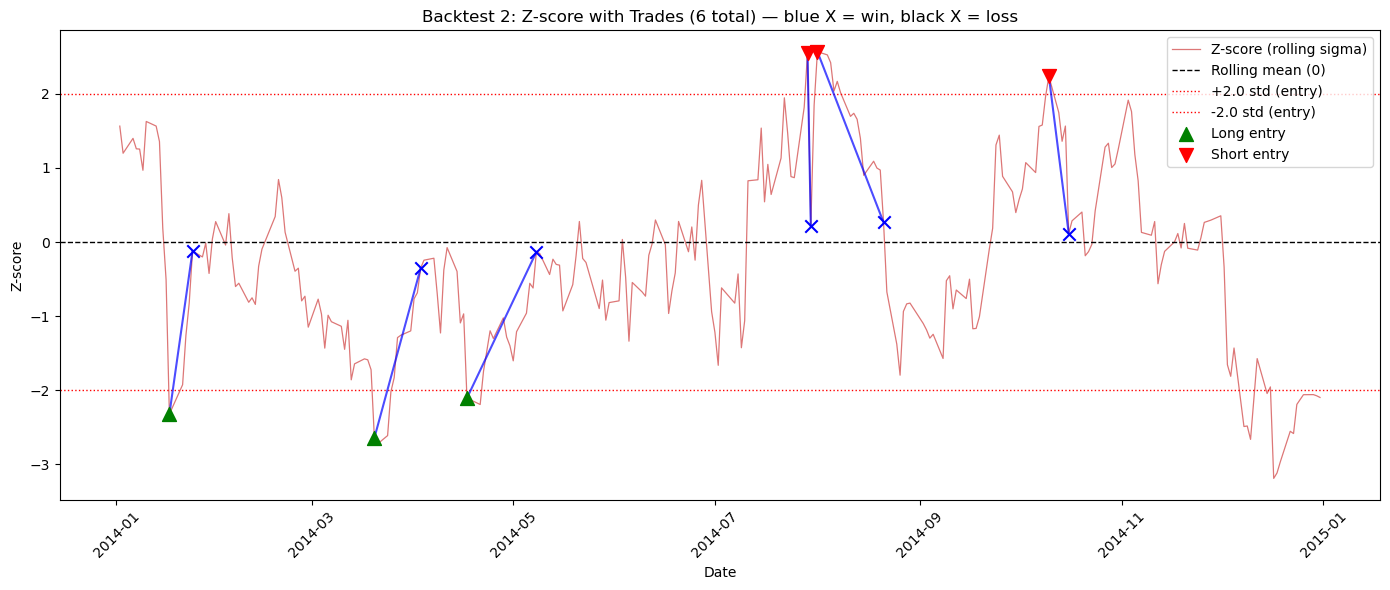

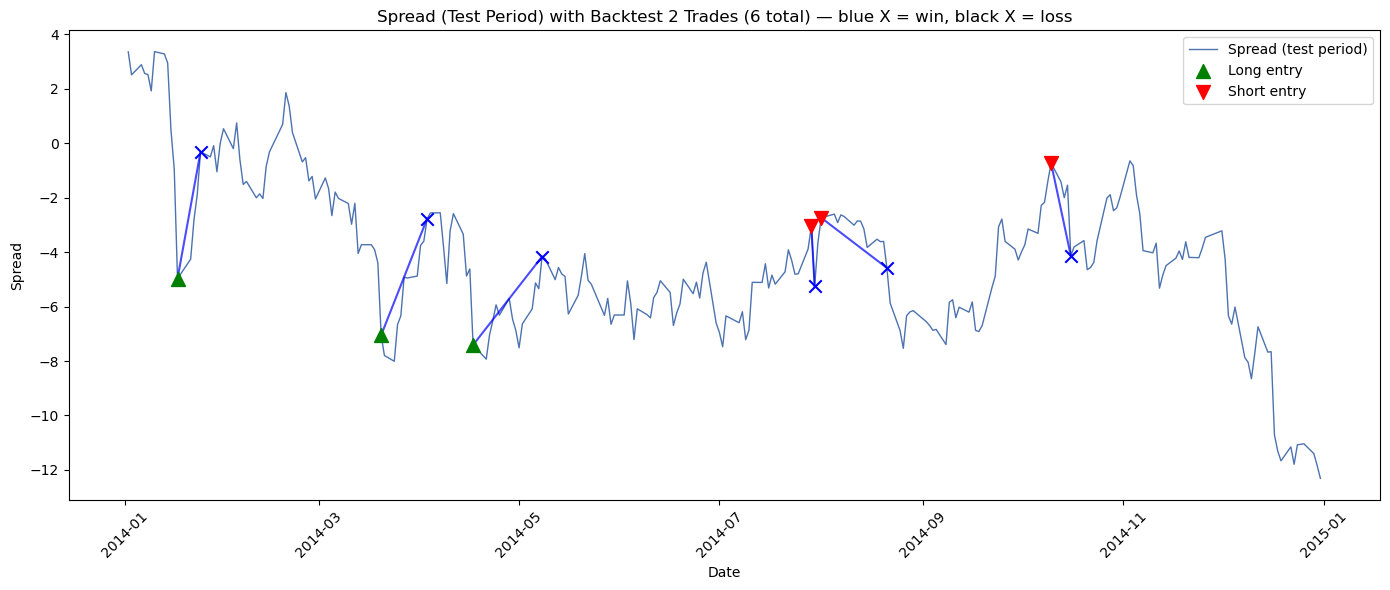


Backtest 1 (frozen):  0 trades
Backtest 2 (rolling): 6 trades


In [ ]:


spread_full = pd.concat([spread_train, spread_test])

WINDOW = 60
rolling_mu = spread_full.rolling(window=WINDOW).mean()
rolling_sigma = spread_full.rolling(window=WINDOW).std()

z_test_v2 = (spread_test - rolling_mu.loc[spread_test.index]) / rolling_sigma.loc[spread_test.index]

print("Max |z| with rolling sigma:", z_test_v2.abs().max())
position = 0
entry_price = None
entry_date = None
trades_v2 = []

for date, z in z_test_v2.items():
    if position == 0:
        if ENTRY_Z < z <= STOP_Z:
            position = -1
            entry_price = spread_test.loc[date]
            entry_date = date
        elif -STOP_Z <= z < -ENTRY_Z:
            position = 1
            entry_price = spread_test.loc[date]
            entry_date = date
    else:
        took_profit = abs(z) < EXIT_Z
        hit_stop_loss = abs(z) > STOP_Z

        if took_profit or hit_stop_loss:
            exit_price = spread_test.loc[date]

            if position == 1:
                pnl = exit_price - entry_price
            else:
                pnl = entry_price - exit_price

            direction = 'long' if position == 1 else 'short'
            days_held = (date - entry_date).days

            trades_v2.append({
                'entry_date': entry_date,
                'exit_date': date,
                'direction': direction,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'pnl': pnl,
                'days_held': days_held
            })

            position = 0
            entry_price = None
            entry_date = None

trades_df_v2 = pd.DataFrame(trades_v2)
num_trades_v2 = len(trades_df_v2)

if num_trades_v2 == 0:
    print("No trades were taken in this period (rolling version).")
else:
    wins_v2 = trades_df_v2[trades_df_v2['pnl'] > 0]
    losses_v2 = trades_df_v2[trades_df_v2['pnl'] <= 0]

    win_rate_v2 = len(wins_v2) / num_trades_v2
    avg_win_v2 = wins_v2['pnl'].mean() if len(wins_v2) > 0 else 0
    avg_loss_v2 = losses_v2['pnl'].mean() if len(losses_v2) > 0 else 0
    total_pnl_v2 = trades_df_v2['pnl'].sum()
    avg_days_held_v2 = trades_df_v2['days_held'].mean()

    print(f"\nBACKTEST 2 RESULTS (rolling {WINDOW}-day sigma)")
    print(f"\nNumber of trades:   {num_trades_v2}")
    print(f"Winning trades:     {len(wins_v2)}")
    print(f"Losing trades:      {len(losses_v2)}")
    print(f"Win rate:           {win_rate_v2:.1%}")
    print(f"Average win:        {avg_win_v2:.2f}")
    print(f"Average loss:       {avg_loss_v2:.2f}")
    print(f"Total P&L:          {total_pnl_v2:.2f}")
    print(f"Average days held:  {avg_days_held_v2:.1f}")

plt.figure(figsize=(14, 6))
plt.plot(z_test_v2, color='#DD7777', lw=0.9, label='Z-score (rolling sigma)', zorder=1)
plt.axhline(0, color='black', linestyle='--', lw=1, label='Rolling mean (0)')
plt.axhline(ENTRY_Z, color='red', linestyle=':', lw=1, label=f'+{ENTRY_Z} std (entry)')
plt.axhline(-ENTRY_Z, color='red', linestyle=':', lw=1, label=f'-{ENTRY_Z} std (entry)')

labeled_long = False
labeled_short = False

for _, trade in trades_df_v2.iterrows():
    entry_z = z_test_v2.loc[trade['entry_date']]
    exit_z = z_test_v2.loc[trade['exit_date']]

    if trade['direction'] == 'long':
        color = 'green'
        marker = '^'
        label = None if labeled_long else 'Long entry'
        labeled_long = True
    else:
        color = 'red'
        marker = 'v'
        label = None if labeled_short else 'Short entry'
        labeled_short = True

    plt.scatter(trade['entry_date'], entry_z, color=color, marker=marker, s=100, zorder=3, label=label)

    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(trade['exit_date'], exit_z, color=outcome_color, marker='x', s=80, zorder=3)

    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([trade['entry_date'], trade['exit_date']], [entry_z, exit_z],
             color=outcome_color, linestyle=line_style, lw=1.5, alpha=0.7, zorder=2)

plt.title(f'Backtest 2: Z-score with Trades ({len(trades_df_v2)} total) — blue X = win, black X = loss')
plt.xlabel('Date')
plt.ylabel('Z-score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(spread_test, color='#4C72B0', lw=1.0, label='Spread (test period)', zorder=1)


labeled_long = False
labeled_short = False

for _, trade in trades_df_v2.iterrows():
    if trade['direction'] == 'long':
        color = 'green'
        marker = '^'
        label = None if labeled_long else 'Long entry'
        labeled_long = True
    else:
        color = 'red'
        marker = 'v'
        label = None if labeled_short else 'Short entry'
        labeled_short = True

    plt.scatter(trade['entry_date'], trade['entry_price'], color=color, marker=marker,
                s=100, zorder=3, label=label)

    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(trade['exit_date'], trade['exit_price'], color=outcome_color, marker='x', s=80, zorder=3)

    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([trade['entry_date'], trade['exit_date']], [trade['entry_price'], trade['exit_price']],
             color=outcome_color, linestyle=line_style, lw=1.5, alpha=0.7, zorder=2)

plt.title(f'Spread (Test Period) with Backtest 2 Trades ({len(trades_df_v2)} total) — blue X = win, black X = loss')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
print(f"\nBacktest 1 (frozen):  {num_trades} trades")
print(f"Backtest 2 (rolling): {num_trades_v2} trades")



## Step 4: A Third Strategy — GARCH-Based Volatility

Instead of a simple rolling average, let's model volatility properly using a **GARCH(1,1)** model — a standard tool in quantitative finance for capturing the fact that calm and turbulent periods tend to cluster together, rather than showing up randomly. A big move today makes another big move tomorrow more likely; a calm stretch tends to stay calm for a while.

$$\sigma_t^2 = \omega + \alpha \cdot \varepsilon_{t-1}^2 + \beta \cdot \sigma_{t-1}^2$$

Here, $\sigma_t^2$ is tomorrow's forecasted variance, $\omega$ is a baseline floor, $\varepsilon_{t-1}$ is yesterday's shock (how much the spread surprised our model), and $\sigma_{t-1}^2$ is yesterday's own volatility estimate. We fit this model using **train data only**, then walk it forward day by day using only real, already-known shocks — never peeking at future data, so every forecast reflects only what a real trader could have known at that point in time.

### A different kind of signal

This strategy asks a different question than the first two. Instead of checking how far the spread's *overall level* has drifted from its average, it checks whether a single day's *move* was unusually large compared to what GARCH considered normal for that specific day:

$$z_t = \frac{\Delta \text{spread}_t}{\sigma_t}$$

If today's move is much bigger than GARCH expected, we treat it as a signal that the spread may partially reverse — and trade accordingly, using the same entry, exit, and stop-loss logic as before.


                           AR - GARCH Model Results                           
Dep. Variable:                   None   R-squared:                       0.966
Mean Model:                        AR   Adj. R-squared:                  0.966
Vol Model:                      GARCH   Log-Likelihood:               -1449.38
Distribution:                  Normal   AIC:                           2908.76
Method:            Maximum Likelihood   BIC:                           2933.32
                                        No. Observations:                 1005
Date:                Tue, Aug 04 2026   Df Residuals:                     1003
Time:                        00:36:23   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1157  6.063e-02      1.909  5.624e-02 [-3.08

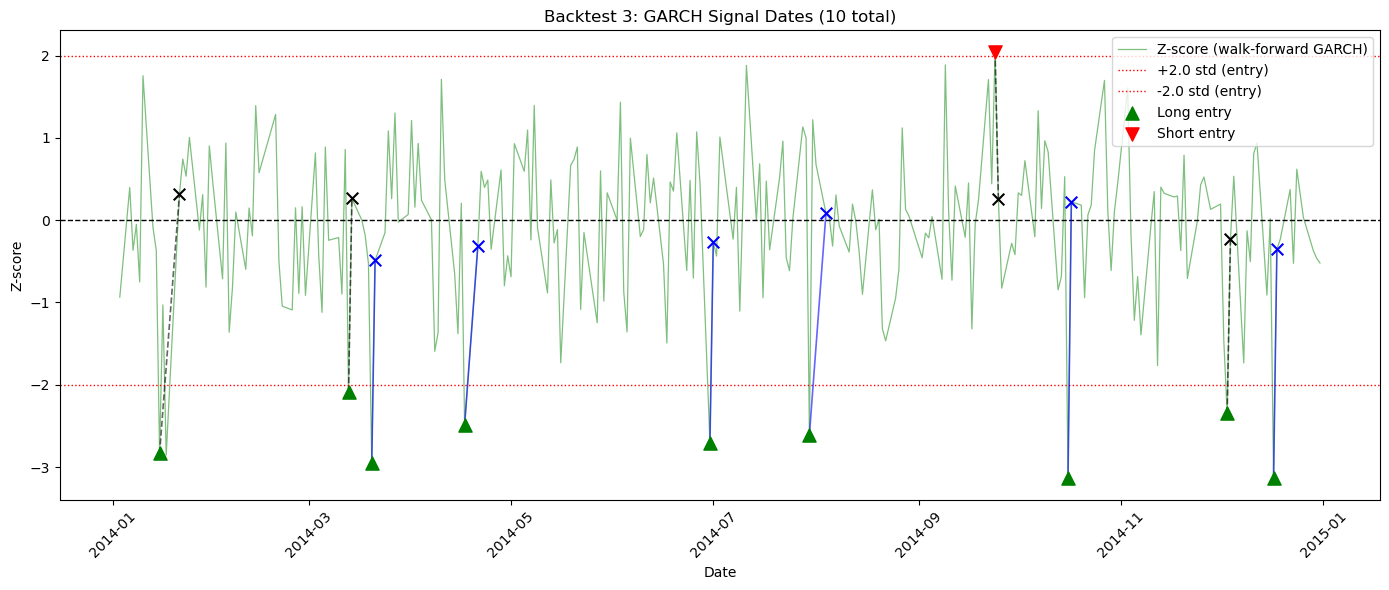

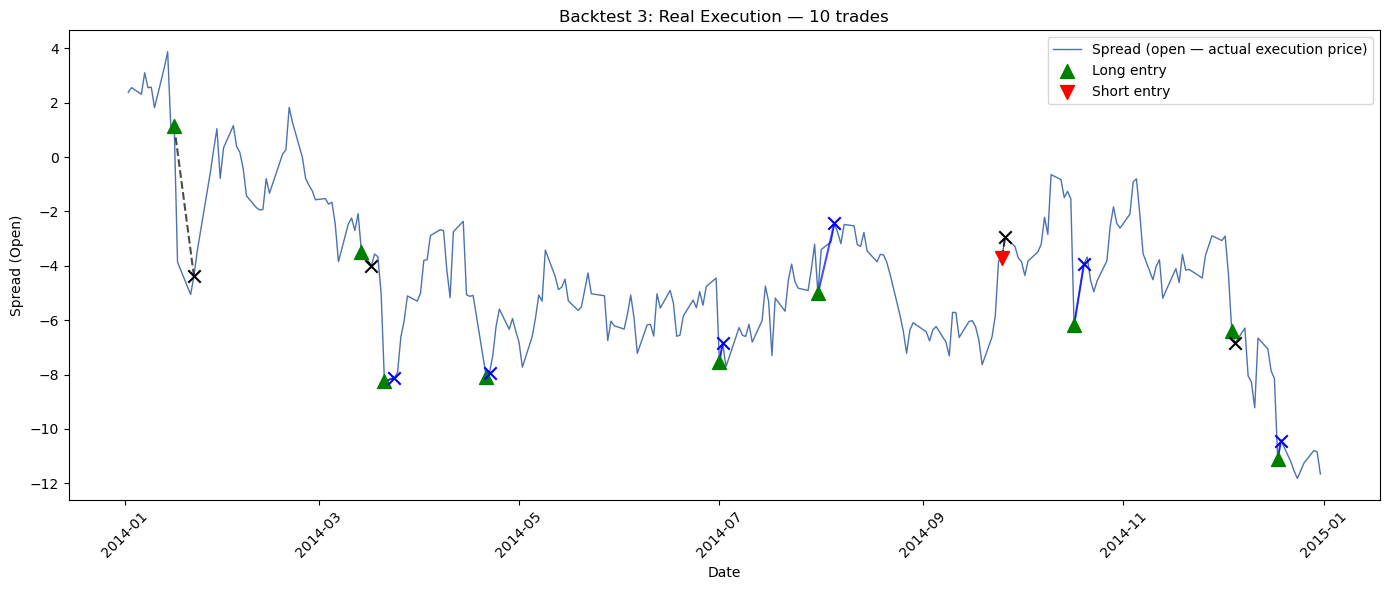

In [ ]:
open_a = df['Open'][ticker_a]
open_b = df['Open'][ticker_b]

opens = pd.DataFrame({'A': open_a, 'B': open_b}).dropna()


norm_open_a = opens['A'] / anchor_a_train * 100
norm_open_b = opens['B'] / anchor_b_train * 100

spread_open = norm_open_a - norm_open_b
spread_open_test = spread_open.loc[spread_test.index]



garch_model_train = arch_model(spread_train, mean='AR', lags=1, vol='Garch', p=1, q=1)
garch_result_train = garch_model_train.fit(disp='off')
print(garch_result_train.summary())

const = garch_result_train.params['Const']
phi = garch_result_train.params['None[1]']
omega = garch_result_train.params['omega']
alpha1 = garch_result_train.params['alpha[1]']
beta1 = garch_result_train.params['beta[1]']

resid_full = (spread_full - const - phi * spread_full.shift(1)).dropna()

uncond_var = omega / (1 - alpha1 - beta1)
sigma2 = pd.Series(index=resid_full.index, dtype=float)
sigma2.iloc[0] = uncond_var

for i in range(1, len(resid_full)):
    sigma2.iloc[i] = omega + alpha1 * resid_full.iloc[i-1]**2 + beta1 * sigma2.iloc[i-1]


vol_walkforward = np.sqrt(sigma2)


spread_change_test = spread_test.diff().dropna()
garch_vol_aligned = vol_walkforward.loc[spread_change_test.index.intersection(vol_walkforward.index)]
spread_change_aligned = spread_change_test.loc[garch_vol_aligned.index]

z_test_v3 = spread_change_aligned / garch_vol_aligned
print("Max |z_test_v3|:", z_test_v3.abs().max())

next_day_open_price = spread_open_test.shift(-1)


position = 0
entry_price = None
entry_date = None
trades_v3 = []

for date, z in z_test_v3.items():
    if position == 0:
        if z > ENTRY_Z:
            position = -1
            entry_price = next_day_open_price.loc[date]
            entry_date = date
        elif z < -ENTRY_Z:
            position = 1
            entry_price = next_day_open_price.loc[date]
            entry_date = date
    else:
        exited_on_calm = abs(z) < EXIT_Z
        hit_stop_loss = abs(z) > STOP_Z

        if exited_on_calm or hit_stop_loss:
            exit_price = next_day_open_price.loc[date]

            if position == 1:
                pnl = exit_price - entry_price
            else:
                pnl = entry_price - exit_price

            direction = 'long' if position == 1 else 'short'
            days_held = (date - entry_date).days

            trades_v3.append({
                'entry_date': entry_date,
                'exit_date': date,
                'direction': direction,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'pnl': pnl,
                'days_held': days_held
            })

            position = 0
            entry_price = None
            entry_date = None


if position != 0 and not pd.isna(entry_price):
    exit_price = spread_test.iloc[-1]
    exit_date = spread_test.index[-1]
    pnl = (exit_price - entry_price) if position == 1 else (entry_price - exit_price)
    direction = 'long' if position == 1 else 'short'
    days_held = (exit_date - entry_date).days
    trades_v3.append({'entry_date': entry_date, 'exit_date': exit_date, 'direction': direction,
                       'entry_price': entry_price, 'exit_price': exit_price, 'pnl': pnl, 'days_held': days_held})

trades_df_v3 = pd.DataFrame(trades_v3)
print(trades_df_v3[['entry_date','exit_date','direction','entry_price','exit_price','pnl']])

num_trades_v3 = len(trades_df_v3)

if num_trades_v3 == 0:
    print("No trades were taken in this period (GARCH walk-forward version).")
else:
    wins_v3 = trades_df_v3[trades_df_v3['pnl'] > 0]
    losses_v3 = trades_df_v3[trades_df_v3['pnl'] <= 0]

    win_rate_v3 = len(wins_v3) / num_trades_v3
    avg_win_v3 = wins_v3['pnl'].mean() if len(wins_v3) > 0 else 0
    avg_loss_v3 = losses_v3['pnl'].mean() if len(losses_v3) > 0 else 0
    total_pnl_v3 = trades_df_v3['pnl'].sum()
    avg_days_held_v3 = trades_df_v3['days_held'].mean()

    print(f"\nBACKTEST 3 RESULTS (walk-forward GARCH)")
    print(f"Number of trades:   {num_trades_v3}")
    print(f"Winning trades:     {len(wins_v3)}")
    print(f"Losing trades:      {len(losses_v3)}")
    print(f"Win rate:           {win_rate_v3:.1%}")
    print(f"Average win:        {avg_win_v3:.2f}")
    print(f"Average loss:       {avg_loss_v3:.2f}")
    print(f"Total P&L:          {total_pnl_v3:.2f}")
    print(f"Average days held:  {avg_days_held_v3:.1f}")


plt.figure(figsize=(14, 6))
plt.plot(z_test_v3, color='#7FBF7F', lw=0.9, label='Z-score (walk-forward GARCH)', zorder=1)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.axhline(ENTRY_Z, color='red', linestyle=':', lw=1, label=f'+{ENTRY_Z} std (entry)')
plt.axhline(-ENTRY_Z, color='red', linestyle=':', lw=1, label=f'-{ENTRY_Z} std (entry)')

labeled_long = False
labeled_short = False

for _, trade in trades_df_v3.iterrows():
    entry_z = z_test_v3.loc[trade['entry_date']]
    exit_z = z_test_v3.loc[trade['exit_date']]

    color = 'green' if trade['direction'] == 'long' else 'red'
    marker = '^' if trade['direction'] == 'long' else 'v'
    label = None if (trade['direction']=='long' and labeled_long) or (trade['direction']=='short' and labeled_short) \
            else ('Long entry' if trade['direction']=='long' else 'Short entry')
    if trade['direction'] == 'long': labeled_long = True
    else: labeled_short = True

    plt.scatter(trade['entry_date'], entry_z, color=color, marker=marker, s=90, zorder=3, label=label)
    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(trade['exit_date'], exit_z, color=outcome_color, marker='x', s=70, zorder=3)
    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([trade['entry_date'], trade['exit_date']], [entry_z, exit_z],
             color=outcome_color, linestyle=line_style, lw=1.2, alpha=0.6, zorder=2)

plt.title(f'Backtest 3: GARCH Signal Dates ({len(trades_df_v3)} total)')
plt.xlabel('Date'); plt.ylabel('Z-score')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()



next_day_date = pd.Series(spread_test.index, index=spread_test.index).shift(-1)

plt.figure(figsize=(14, 6))
plt.plot(spread_open_test, color='#4C72B0', lw=1.0, label='Spread (open — actual execution price)', zorder=1)

labeled_long = False
labeled_short = False

for _, trade in trades_df_v3.iterrows():
    execution_entry_date = next_day_date.loc[trade['entry_date']]
    execution_exit_date = next_day_date.loc[trade['exit_date']]

    color = 'green' if trade['direction'] == 'long' else 'red'
    marker = '^' if trade['direction'] == 'long' else 'v'
    label = None if (trade['direction']=='long' and labeled_long) or (trade['direction']=='short' and labeled_short) \
            else ('Long entry' if trade['direction']=='long' else 'Short entry')
    if trade['direction'] == 'long': labeled_long = True
    else: labeled_short = True

    plt.scatter(execution_entry_date, trade['entry_price'], color=color, marker=marker, s=100, zorder=3, label=label)
    outcome_color = 'blue' if trade['pnl'] > 0 else 'black'
    plt.scatter(execution_exit_date, trade['exit_price'], color=outcome_color, marker='x', s=80, zorder=3)
    line_style = '-' if trade['pnl'] > 0 else '--'
    plt.plot([execution_entry_date, execution_exit_date], [trade['entry_price'], trade['exit_price']],
             color=outcome_color, linestyle=line_style, lw=1.5, alpha=0.7, zorder=2)

plt.title(f'Backtest 3: Real Execution — {len(trades_df_v3)} trades')
plt.xlabel('Date'); plt.ylabel('Spread (Open)')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()


## Step 5: Monte Carlo Simulation — Is the Result Real, or Luck?

Everything so far has been tested on **one single historical path** — the actual prices that happened to occur in our test period. But that's just one outcome out of many that could have happened. If we ran history again with slightly different random events, would our strategies still work, or did we just get lucky (or unlucky) this one time?

To answer that, we simulate **many alternate, statistically realistic versions** of the test period, using the same AR(1) model we fit on the training data — same average level, same reversion strength, same typical day-to-day noise — just with fresh randomness each time. Then we run all three of our trading strategies on every single simulated path, and look at the full range of outcomes.

This tells us something a single backtest never can: not just "did it work this one time," but "how often does it work, and how bad could it realistically get."

### What we're checking for

- **% of simulations profitable** — across many alternate histories, how often does each strategy actually make money?
- **Mean and median P&L** — what's the typical outcome, on average?
- **Worst-case and best-case scenarios** — using the 5th and 95th percentile outcomes, what does a genuinely bad run look like, and what does a genuinely good one look like?

If a strategy performs well across the vast majority of simulated histories, that's real, reproducible evidence of edge. If it barely beats a coin flip, or only looks good because of one lucky historical path, the simulation will reveal that too.

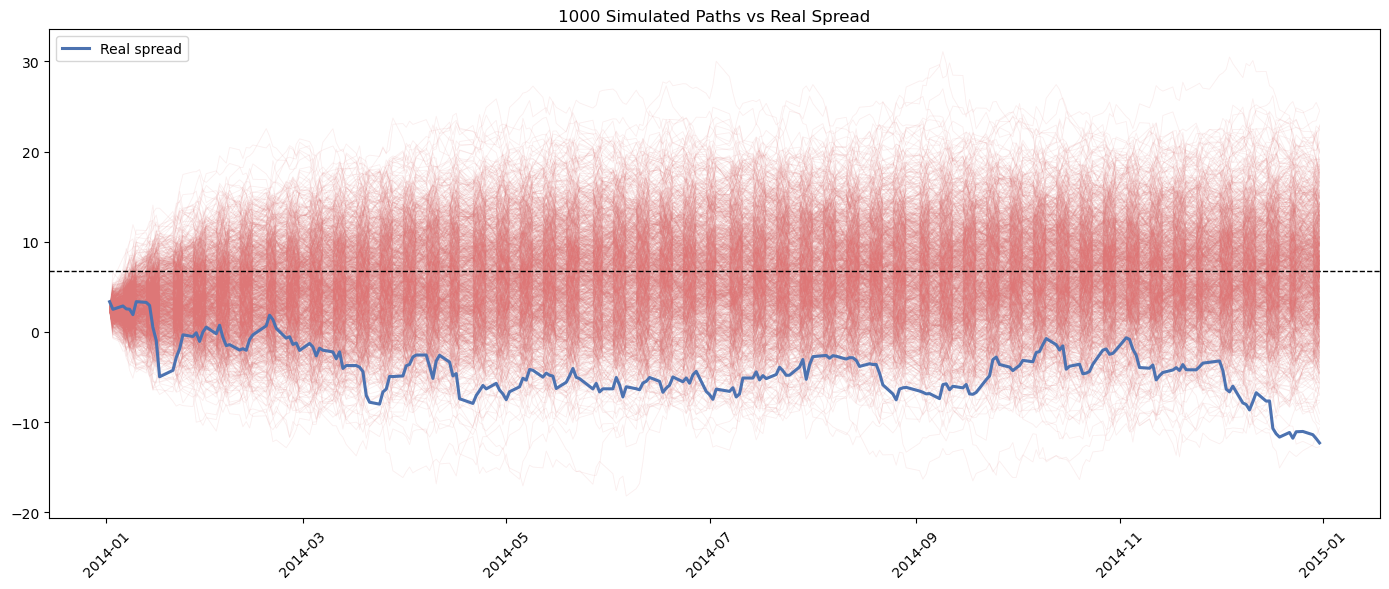

MONTE CARLO  (seed=42, 1000 sims)

Frozen
  profitable: 53%
  mean 5.64   median 3.00
  5th 0.00   95th 19.00
  real -10.95 -> 0% percentile

Rolling
  profitable: 80%
  mean 7.01   median 7.21
  5th -7.96   95th 21.41
  real 19.61 -> 92% percentile

GARCH
  profitable: 55%
  mean 0.60   median 0.62
  5th -8.89   95th 10.46
  real -0.73 -> 41% percentile



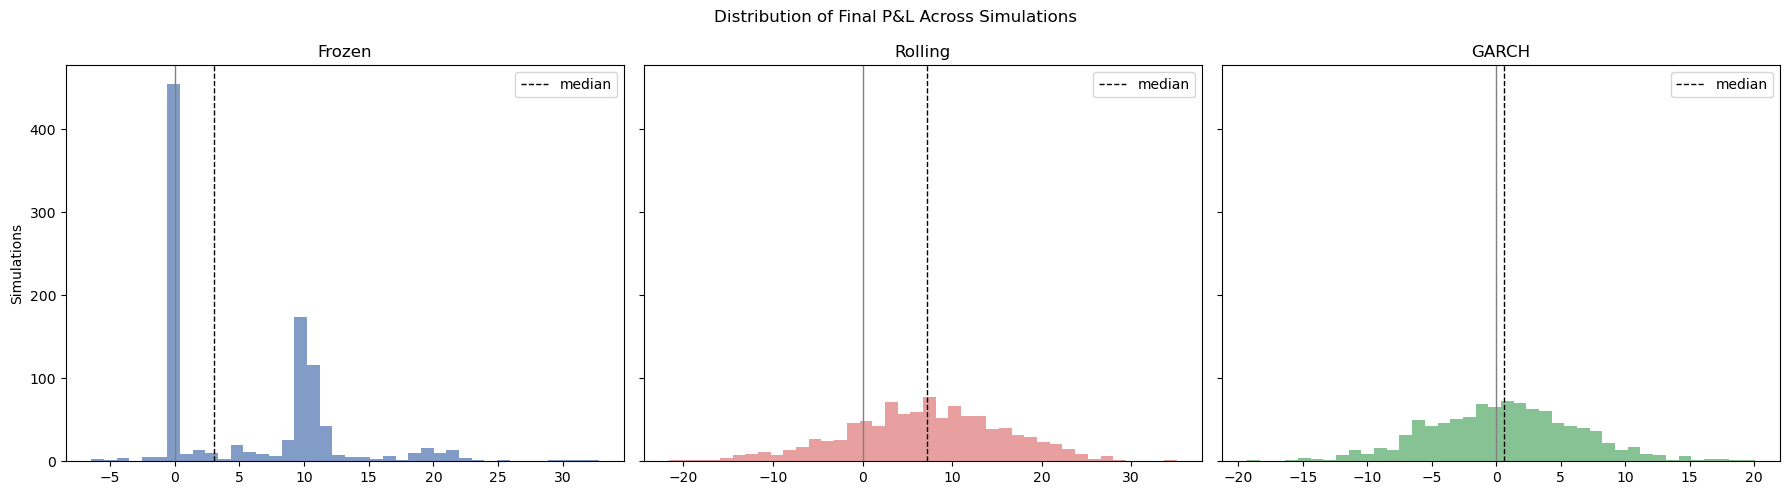

In [ ]:
SEED, N_SIMS, WINDOW = 42, 1000, 60
rng = np.random.default_rng(SEED)

phi = min(lambda_train + 1.0, 0.995)
sigma = model_train2.resid.std()
n = len(spread_test)

paths = np.empty((N_SIMS, n))
paths[:, 0] = spread_train.iloc[-1]
shocks = rng.normal(0, sigma, (N_SIMS, n))
for t in range(1, n):
    paths[:, t] = mu_train + phi * (paths[:, t-1] - mu_train) + shocks[:, t]

sims = [pd.Series(p, index=spread_test.index) for p in paths]

plt.figure(figsize=(14, 6))
for s in sims:
    plt.plot(s, color='#DD7777', alpha=0.12, lw=0.6)
plt.plot(spread_test, color='#4C72B0', lw=2.2, label='Real spread')
plt.axhline(mu_train, color='black', ls='--', lw=1)
plt.title(f'{N_SIMS} Simulated Paths vs Real Spread')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


def run_level(spread, z):
    pos, entry, pnl = 0, 0, 0.0
    for d in z.index:
        zz = z[d]
        if pd.isna(zz):
            continue
        if pos == 0 and abs(zz) > ENTRY_Z:
            pos, entry = (-1 if zz > 0 else 1), spread[d]
        elif pos != 0 and (abs(zz) < EXIT_Z or abs(zz) > STOP_Z):
            pnl += pos * (spread[d] - entry); pos = 0
    if pos != 0:
        pnl += pos * (spread[z.index[-1]] - entry)
    return pnl

def run_garch(spread, z):
    nxt = spread.shift(-1)
    pos, entry, pnl = 0, 0, 0.0
    for d in z.index:
        zz, px = z[d], nxt.get(d, np.nan)
        if pd.isna(zz) or pd.isna(px):
            continue
        if pos == 0 and abs(zz) > ENTRY_Z:
            pos, entry = (-1 if zz > 0 else 1), px
        elif pos != 0 and (abs(zz) < EXIT_Z or abs(zz) > STOP_Z):
            pnl += pos * (px - entry); pos = 0
    if pos != 0:
        pnl += pos * (spread[z.index[-1]] - entry)
    return pnl


pnl_1, pnl_2, pnl_3 = [], [], []
for s in sims:
    full = pd.concat([spread_train.tail(100), s])

    z1 = (s - mu_train) / sigma_train
    pnl_1.append(run_level(s, z1))

    mean = full.rolling(WINDOW).mean().loc[s.index]
    std = full.rolling(WINDOW).std().loc[s.index]
    z2 = (s - mean) / std
    pnl_2.append(run_level(s, z2))

    resid = (full - const - phi * full.shift(1)).dropna()
    v = np.empty(len(resid)); v[0] = uncond_var
    r = resid.values
    for t in range(1, len(r)):
        v[t] = omega + alpha1 * r[t-1]**2 + beta1 * v[t-1]
    vol = pd.Series(np.sqrt(v), index=resid.index)
    chg = full.diff().dropna()
    idx = chg.index.intersection(vol.index).intersection(s.index)
    z3 = chg[idx] / vol[idx]
    pnl_3.append(run_garch(s, z3))

pnl_1, pnl_2, pnl_3 = pd.Series(pnl_1), pd.Series(pnl_2), pd.Series(pnl_3)

print(f"MONTE CARLO  (seed={SEED}, {N_SIMS} sims)\n")
real_v2 = float(globals().get("total_pnl_v2", pnl_2.median()))

results = [
    ("Frozen", pnl_1, float(total_pnl)),
    ("Rolling", pnl_2, real_v2),
    ("GARCH", pnl_3, float(total_pnl_v3)),
]

for name, pnl, real in results:
    print(f"{name}")
    print(f"  profitable: {(pnl > 0).mean():.0%}")
    print(f"  mean {pnl.mean():.2f}   median {pnl.median():.2f}")
    print(f"  5th {pnl.quantile(.05):.2f}   95th {pnl.quantile(.95):.2f}")
    print(f"  real {real:.2f} -> {(pnl < real).mean():.0%} percentile\n")


def equity(pnl_list):
    return pd.Series(pnl_list).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#4C72B0', '#DD7777', '#55A868']
data = [pnl_1, pnl_2, pnl_3]
names = ['Frozen', 'Rolling', 'GARCH']

for ax, pnl, name, c in zip(axes, data, names, colors):
    ax.hist(pnl, bins=40, color=c, alpha=0.7)
    ax.axvline(pnl.median(), color='black', ls='--', lw=1, label='median')
    ax.axvline(0, color='gray', lw=1)
    ax.set_title(name); ax.legend()
axes[0].set_ylabel('Simulations')
plt.suptitle('Distribution of Final P&L Across Simulations')
plt.tight_layout(); plt.show()



## Final Verdict

We've come a long way — from raw prices, to statistical tests, to three competing strategies, to a thousand simulated alternate universes. So... did this whole approach actually hold up? Let's find out.

### The Foundation
Our four statistical tests are what decide whether a pair is even worth trading in the first place. A pair that passes all four — real correlation, a genuine pull back toward the mean, a reasonably short half-life, and a clean ADF result — gives you a solid foundation to build on. A pair that only partially passes, or lands right on the edge of significance, is still workable, but deserves a healthier dose of skepticism about how strong the edge really is.

### Strategy 1 — Frozen Volatility
This approach calibrates its sense of "normal" once, at the start, and never checks again. The risk here is obvious in hindsight: markets don't stay put. If conditions shift after that calibration — calmer, wilder, whatever — a frozen threshold can quietly stop making sense, sitting out trades it should be taking, or misjudging the ones it does take. Running this through many simulated alternate histories is exactly how you catch that kind of staleness before it costs you anything real.

### Strategy 2 — Rolling Volatility
By recalculating "normal" fresh, using only recent data, this approach stays current instead of relying on a stale snapshot. When a strategy like this comes out profitable across the majority of simulated alternate histories — not just the one real path you happened to test — that's the strongest kind of evidence you can get that the edge is real, not a lucky accident of history.

### Strategy 3 — Model-Based Volatility (e.g. GARCH)
A properly fitted volatility model can genuinely capture real structure — like the fact that turbulent periods tend to cluster together. But a model being *accurate* doesn't automatically mean a strategy built on top of it is *profitable*. If the very thing the model measures (like a standardized shock) is, by its own statistical design, close to unpredictable, betting on it directly can land close to a coin flip — a useful, honest finding in its own right, not a wasted effort.

### So, What's the Real Takeaway?
The strategy that adapts to *current* conditions, and whose edge holds up across many simulated alternate histories — not just one lucky backtest — is the one worth trusting. A single historical result, no matter how good it looks, is never enough on its own to prove a strategy actually works.

### Before You Trade Any of This For Real
None of this accounts for transaction costs, slippage, or borrowing fees, all of which chip away at real-world returns. Test on more than one pair before drawing broad conclusions, and always check how borderline your underlying statistical signal really is — the closer it sits to the edge of significance, the more cautious you should be about trusting the results. Treat a project like this as a demonstration of *rigorous process* — not a green light to trade tomorrow morning.

## Wrapping Up

That's the full pipeline, start to finish: building the spread, testing whether it actually mean-reverts, building three different trading strategies around it, and stress-testing all three against a thousand simulated alternate histories before trusting any of them.

A few natural next steps, if you wanted to keep pushing this further:
- Test the same pipeline on other pairs, to see whether the winning strategy's edge holds up more broadly, or was specific to this one relationship
- Add realistic transaction costs and slippage to see how much they eat into the results
- Try combining the volatility model with the rolling-volatility strategy, rather than testing them separately, since each caught something the other missed
- You can also add Kalman filters.

Thanks for following along — hope this was as useful to read through as it was to build!